In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

r = pd.read_csv('results_v2.csv')
r = r.drop_duplicates(['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')
ALL = r[r.tranche=='all'].copy()   # most comparisons use all-flows

def barh(series, title, xlabel='log-R²'):
    fig, ax = plt.subplots(figsize=(8, max(2, 0.5*len(series))))
    colors = ['#2ca02c' if v>0 else '#d62728' for v in series.values]
    ax.barh(series.index, series.values, color=colors)
    ax.axvline(0, color='k', lw=0.6); ax.set_xlabel(xlabel); ax.set_title(title)
    for i,v in enumerate(series.values): ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

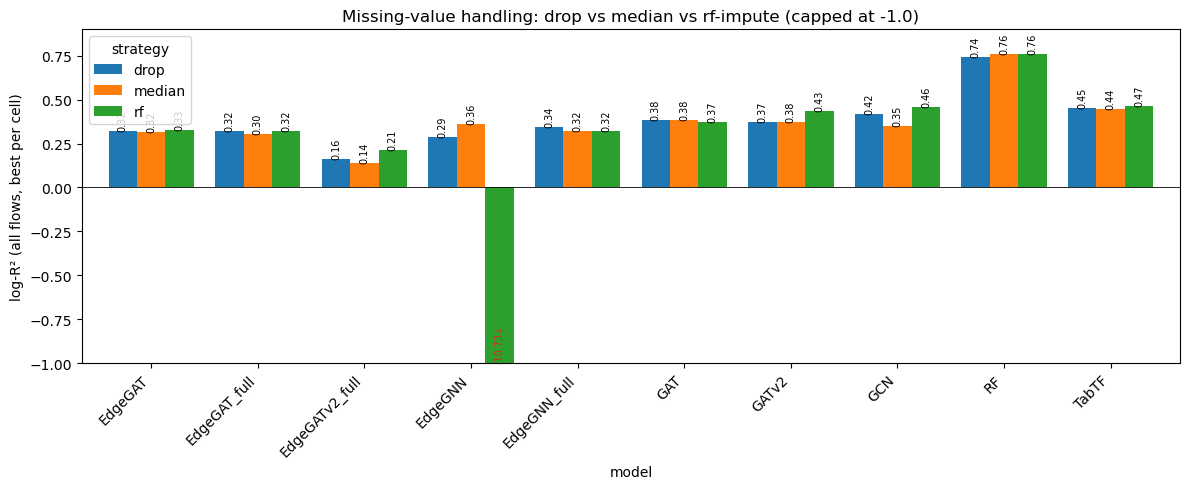

missing          drop  median      rf
model                                
EdgeGAT         0.324   0.315   0.326
EdgeGAT_full    0.320   0.302   0.323
EdgeGATv2_full  0.163   0.139   0.213
EdgeGNN         0.285   0.362 -10.730
EdgeGNN_full    0.342   0.321   0.320
GAT             0.383   0.385   0.373
GATv2           0.370   0.375   0.435
GCN             0.416   0.351   0.460
RF              0.744   0.761   0.759
TabTF           0.450   0.445   0.465


In [6]:
m = ALL[ALL.missing.isin(['drop','median','rf'])]
piv = m.pivot_table(index='model', columns='missing', values='log_r2', aggfunc='max').dropna(how='all')

CAP_LO = -1.0                                   # anything below this is "off-scale"
ax = piv.plot(kind='bar', figsize=(12,5), width=0.8)
plt.axhline(0, color='k', lw=0.6)
plt.ylim(CAP_LO, max(0.9, piv.max().max()*1.15))   # cap the view
plt.ylabel('log-R² (all flows, best per cell)')
plt.title(f'Missing-value handling: drop vs median vs rf-impute (capped at {CAP_LO})')
plt.xticks(rotation=45, ha='right'); plt.legend(title='strategy')

# value label on every bar; mark the ones that ran off the bottom
for p in ax.patches:
    h = p.get_height()
    if np.isnan(h): continue
    x = p.get_x()+p.get_width()/2
    if h < CAP_LO:
        ax.annotate(f'{h:.2f}↓', (x, CAP_LO), ha='center', va='bottom',
                    fontsize=7, rotation=90, color='#d62728')
    else:
        ax.annotate(f'{h:.2f}', (x, h), ha='center',
                    va='bottom' if h>=0 else 'top', fontsize=7, rotation=90)
plt.tight_layout(); plt.show()
print(piv.round(3))

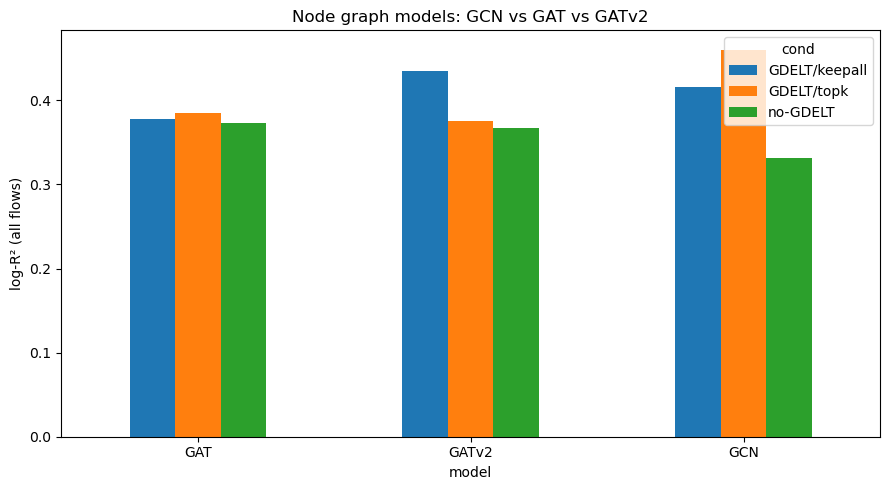

cond   GDELT/keepall  GDELT/topk  no-GDELT
model                                     
GAT            0.378       0.385     0.373
GATv2          0.435       0.375     0.368
GCN            0.416       0.460     0.331


In [3]:
# fair comparison: same conditions, node models only
nodes = ALL[ALL.model.isin(['GCN','GAT','GATv2'])].copy()
nodes['cond'] = np.where(~nodes.gdelt, 'no-GDELT', 'GDELT/'+nodes.scoring.astype(str))
piv = nodes.pivot_table(index='model', columns='cond', values='log_r2', aggfunc='max')
piv.plot(kind='bar', figsize=(9,5)); plt.axhline(0,color='k',lw=0.6)
plt.ylabel('log-R² (all flows)'); plt.title('Node graph models: GCN vs GAT vs GATv2')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(piv.round(3))

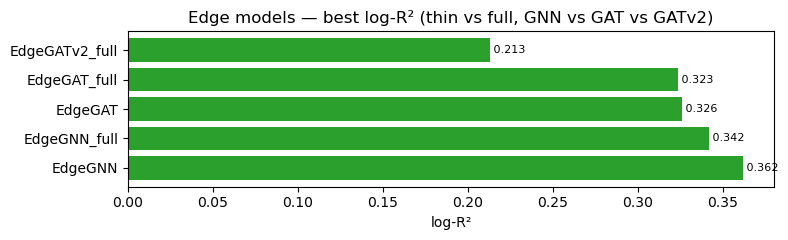

model
EdgeGNN           0.362
EdgeGNN_full      0.342
EdgeGAT           0.326
EdgeGAT_full      0.323
EdgeGATv2_full    0.213
Name: log_r2, dtype: float64


In [4]:
edge = ALL[ALL.model.str.contains('Edge')].copy()
best = edge.groupby('model')['log_r2'].max().sort_values(ascending=False)
barh(best, 'Edge models — best log-R² (thin vs full, GNN vs GAT vs GATv2)')
print(best.round(3))

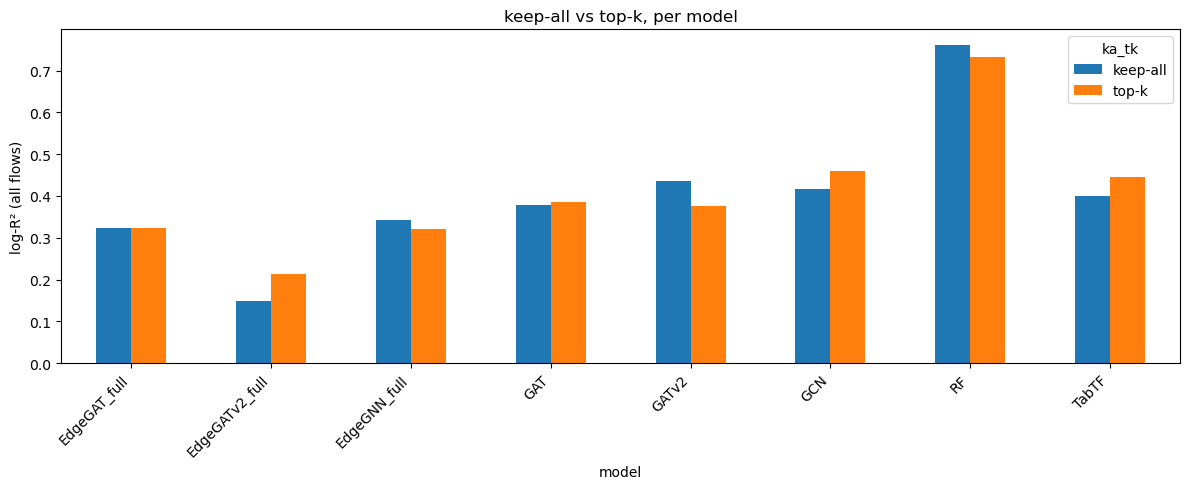

ka_tk           keep-all  top-k
model                          
EdgeGAT_full       0.323  0.323
EdgeGATv2_full     0.149  0.213
EdgeGNN_full       0.342  0.320
GAT                0.378  0.385
GATv2              0.435  0.375
GCN                0.416  0.460
RF                 0.761  0.732
TabTF              0.400  0.445

Wins — keep-all vs top-k: 3 vs 5


In [5]:
# node side: scoring in {keepall, topk}; edge side: combos encode both (ka_*/tk_*)
def scorer_family(row):
    s = str(row['scoring'])
    if s in ('keepall',): return 'keep-all'
    if s in ('topk',):    return 'top-k'
    if s.startswith('ka'):return 'keep-all (node)'
    if s.startswith('tk'):return 'top-k (node)'
    return None

g = ALL[ALL.gdelt==True].copy()
g['family'] = g.apply(scorer_family, axis=1)
g = g.dropna(subset=['family'])
# simplify to the core question: keepall vs topk on the NODE scorer
g['ka_tk'] = np.where(g.family.str.contains('keep'), 'keep-all', 'top-k')
summary = g.groupby(['model','ka_tk'])['log_r2'].max().unstack()
summary.plot(kind='bar', figsize=(12,5)); plt.axhline(0,color='k',lw=0.6)
plt.ylabel('log-R² (all flows)'); plt.title('keep-all vs top-k, per model')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print(summary.round(3))
print('\nWins — keep-all vs top-k:',
      (summary['keep-all']>summary['top-k']).sum(), 'vs',
      (summary['top-k']>summary['keep-all']).sum())